# Tyre degradation & pit-stop strategy — Formula 1, 2026 season

**Question.** How fast do the tyres degrade in 2026, does it depend on the compound or on the
track, and when was the optimal moment to pit?

**Data.** Every race lap of the 2026 season from [OpenF1](https://openf1.org): lap and sector
times, tyre compound and age, pit stops, Safety Car / VSC / flags, track temperature.
Built with `python -m analysis.dataset 2026` (code in [`analysis/`](../analysis)).

**TL;DR** (15 races at the time of writing):
1. A naive season-wide model says the **SOFT tyre degrades slower than MEDIUM** — a Simpson's
   paradox: teams use the soft mostly on low-degradation tracks.
2. Within the same race the three compounds degrade at similar rates; **the track matters far
   more than the compound** (from ≈0 to 0.15 s/lap).
3. Forecasting lap times inside a stint: a season-average degradation barely helps on a new
   track (−2 % error vs. "pace stays flat"), a **track-specific** estimate learned from the other
   drivers in the same race cuts the error by **≈20 %**.
4. On a race where the model fits well (Belgium) the optimal one-stop lap it predicts
   **matches what the teams actually did** within one lap.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sys; sys.path.insert(0, '..')
from analysis.clean import clean_laps
from analysis import model as M, strategy as S

warnings.filterwarnings('ignore')
pd.set_option('display.precision', 3)
plt.rcParams.update({'figure.figsize': (9, 4.2), 'figure.dpi': 110, 'axes.grid': True,
                     'grid.alpha': .25, 'axes.spines.top': False, 'axes.spines.right': False})
COLORS = {'SOFT': '#e10600', 'MEDIUM': '#f2b705', 'HARD': '#7a7f8c'}

path = Path('../data/laps_2026.parquet')
if not path.exists():                       # собрать датасет (≈3 мин, дальше из кеша)
    from analysis.dataset import build_laps
    path.parent.mkdir(exist_ok=True)
    build_laps(2026).to_parquet(path, index=False)
laps = pd.read_parquet(path)
print(f'{len(laps):,} laps · {laps.race.nunique()} races · {laps.driver.nunique()} drivers')

17,260 laps · 15 races · 23 drivers


## 1. Data
One row per lap per driver. Races per round:

In [2]:
laps.groupby(['round', 'race']).agg(
    laps=('lap_number', 'size'), race_laps=('total_laps', 'first'),
    neutralised=('neutralised', lambda s: s.notna().mean()),
    track_temp=('track_temperature', 'mean')).round(2)

,,laps,race_laps,neutralised,track_temp
round,race,,,,
1,Australian Grand Prix,1002,58,0.13,36.34
2,Chinese Grand Prix,924,56,0.07,21.46
3,Japanese Grand Prix,1108,53,0.12,32.64
6,Miami Grand Prix,1042,57,0.12,38.20
7,Canadian Grand Prix,1212,68,0.09,18.31
8,Monaco Grand Prix,1452,78,0.12,40.79
9,Barcelona Grand Prix,1241,66,0.08,50.02
10,Austrian Grand Prix,1342,71,0.06,51.07
11,British Grand Prix,1114,52,0.16,40.36


## 2. Cleaning
Tyre degradation has to be measured on *representative* laps only. Each discarded lap gets
the first rule it fails: start lap, pit in/out laps, laps under Safety Car / VSC / red flag,
yellow flags, wet running, outliers (>107 % of the driver's median in that race) and stints with
fewer than 4 clean laps left.

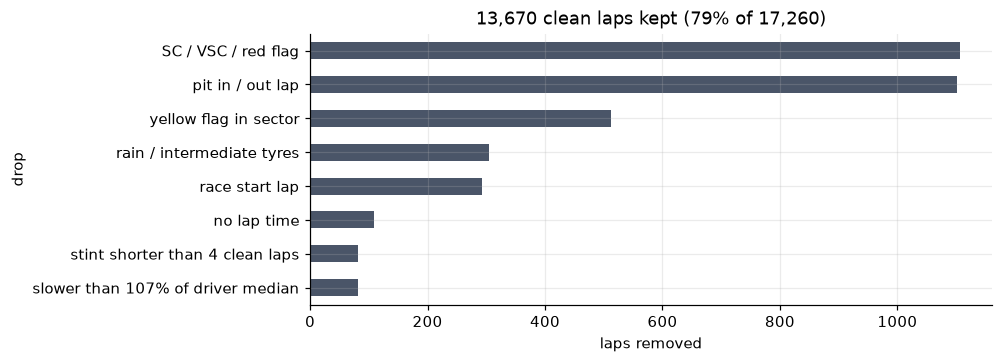

In [3]:
clean, report = clean_laps(laps)
ax = report.sort_values().plot.barh(color='#4a5568', figsize=(8, 3.2))
ax.set(xlabel='laps removed', title=f'{len(clean):,} clean laps kept '
       f'({len(clean) / len(laps):.0%} of {len(laps):,})')
plt.show()

## 3. A first look: two extremes
Fuel-corrected lap time relative to the first clean lap of each stint, against laps into the
stint — at the highest- and lowest-wear tracks of the season. (Pooling all tracks into one chart
would mix them up: only low-wear tracks produce long stints — a survivorship effect.)

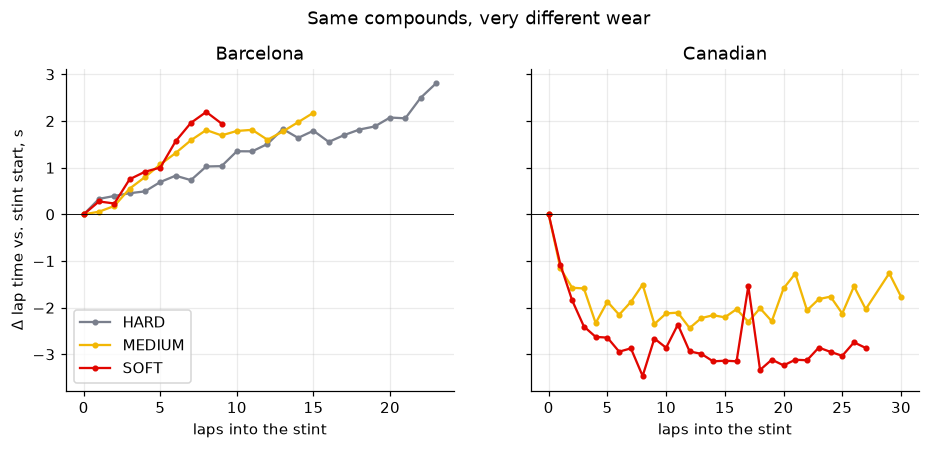

In [4]:
season = M.fit_season(clean)
fuel, fuel_lo, fuel_hi = M.fuel_effect(season)

d = clean.assign(t=clean.lap_time - fuel * clean.laps_remaining)
key = ['session_key', 'driver_number', 'stint']
d['dt'] = d.t - d.groupby(key).t.transform('first')
d['into'] = d.tyre_age - d.groupby(key).tyre_age.transform('first')

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, race in zip(axes, ['Barcelona Grand Prix', 'Canadian Grand Prix']):
    for c, g in d[d.race == race].groupby('compound'):
        m = g.groupby('into').dt.agg(['median', 'size'])
        m = m[(m['size'] >= 5) & (m.index <= 30)]
        ax.plot(m.index, m['median'], 'o-', ms=3, color=COLORS[c], label=c)
    ax.axhline(0, color='k', lw=.6)
    ax.set(title=race.replace(' Grand Prix', ''), xlabel='laps into the stint')
axes[0].set_ylabel('Δ lap time vs. stint start, s'); axes[0].legend()
fig.suptitle('Same compounds, very different wear', y=1.02); plt.show()

In Barcelona every compound loses ~2 s over 15 laps. In Canada laps get **faster**
through the stint: the track was rubbering in, and the first lap of a stint is often still on
cold tyres. Keep this in mind — it is the main source of noise in everything below.

## 4. A naive season model — and a paradox
Linear mixed model over all races (random intercept per race × driver = car pace on that track):

`lap_time ~ compound + compound:tyre_age + laps_remaining (fuel) + track_temperature`

In [5]:
print(f'fuel effect: {fuel:.3f} s per lap of fuel  (95% CI {fuel_lo:.3f}–{fuel_hi:.3f})')
M.degradation(season)

fuel effect: 0.044 s per lap of fuel  (95% CI 0.043–0.045)


,deg_s_per_lap,ci_low,ci_high,p_value
compound,,,,
SOFT,0.018,0.013,0.022,2.654e-15
MEDIUM,0.032,0.029,0.035,1.975e-90
HARD,0.028,0.025,0.030,2.964e-112


The fuel effect is plausible (≈0.04 s/lap is the usual paddock rule of thumb), but the
**soft tyre comes out as the most durable compound**, which contradicts how tyres work.

Hypothesis: confounding by track. Pirelli brings the same three names to every race, and teams
run the soft mostly where it lasts — on low-degradation circuits.

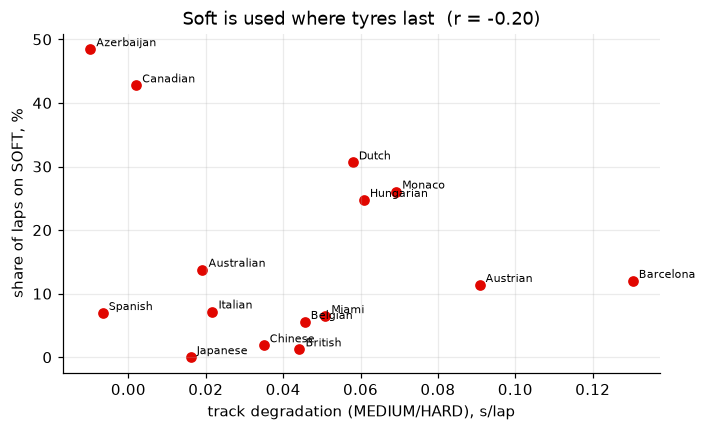

In [6]:
fuel_fixed = fuel
by_race = M.deg_by_race(clean, fuel_fixed)
track_level = by_race[by_race.compound != 'SOFT'].groupby('race').deg_s_per_lap.mean()
soft_share = clean.groupby('race').compound.apply(lambda s: (s == 'SOFT').mean())
x = pd.concat([track_level.rename('track_deg'), soft_share.rename('soft_share')], axis=1).dropna()

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x.track_deg, x.soft_share * 100, color=COLORS['SOFT'])
for race, r in x.iterrows():
    ax.annotate(race.replace(' Grand Prix', ''), (r.track_deg, r.soft_share * 100),
                fontsize=7, xytext=(4, 2), textcoords='offset points')
ax.set(xlabel='track degradation (MEDIUM/HARD), s/lap', ylabel='share of laps on SOFT, %',
       title=f'Soft is used where tyres last  (r = {x.corr().iloc[0, 1]:.2f})')
plt.show()

## 5. Degradation is a property of the track
Same model fitted **inside each race** (driver as a fixed effect, fuel fixed at the season value).
Bars are 95 % confidence intervals.

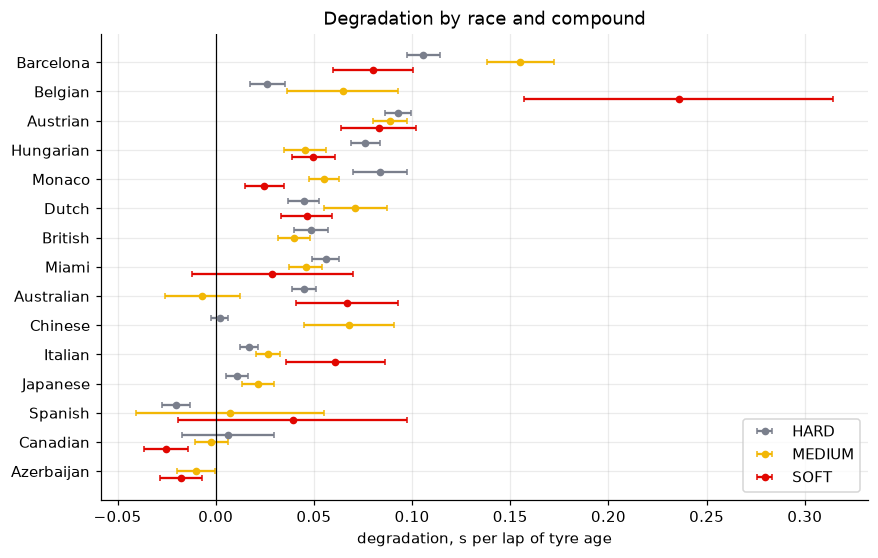

In [7]:
order = by_race.groupby('race').deg_s_per_lap.mean().sort_values().index
fig, ax = plt.subplots(figsize=(9, 5.5))
offs = {'SOFT': -0.25, 'MEDIUM': 0, 'HARD': 0.25}
for c, g in by_race.groupby('compound'):
    y = np.array([list(order).index(r) for r in g.race]) + offs[c]
    ax.errorbar(g.deg_s_per_lap, y, xerr=[g.deg_s_per_lap - g.ci_low, g.ci_high - g.deg_s_per_lap],
                fmt='o', ms=4, color=COLORS[c], label=c, capsize=2)
ax.set_yticks(range(len(order)), [r.replace(' Grand Prix', '') for r in order])
ax.axvline(0, color='k', lw=.8)
ax.set(xlabel='degradation, s per lap of tyre age', title='Degradation by race and compound')
ax.legend(loc='lower right'); plt.show()

In [8]:
rows = []
for c in ('SOFT', 'HARD'):
    diff = M.paired_compound_diff(by_race, c)
    rows.append({'comparison': f'{c} − MEDIUM', 'races': len(diff), 'median diff, s/lap': diff.median(),
                 'races where it degrades faster': f'{int((diff > 0).sum())} of {len(diff)}'})
spread = by_race.groupby('race').deg_s_per_lap.mean()
print(f'track-to-track spread of degradation: {spread.min():.3f} … {spread.max():.3f} s/lap '
      f'(std {spread.std():.3f})')
pd.DataFrame(rows)

track-to-track spread of degradation: -0.014 … 0.114 s/lap (std 0.037)


,comparison,races,"median diff, s/lap",races where it degrades faster
0,SOFT − MEDIUM,12,-0.007,5 of 12
1,HARD − MEDIUM,14,-0.003,7 of 14


Within the same race the compounds are close: the median difference between soft and
medium is a few thousandths of a second per lap and goes either way. The spread **between
tracks** is an order of magnitude larger. Negative estimates (Canada, Baku, Madrid) mean the
track was getting faster ("rubbering in") quicker than the tyres were wearing — the model
cannot separate the two, see *Limitations*.

## 6. Does it predict anything?
Task: after the first 3 clean laps of a stint, predict every following lap time.
* **baseline** — pace stays flat;
* **season model** — season-average degradation, trained *without* this race (leave-one-race-out);
* **track model** — degradation of *this* track, learned from the **other drivers** in the same race
  (leave-one-driver-out) — what a strategist can actually do during a race.

In [9]:
loro = M.leave_one_race_out(clean)
lodo = M.leave_one_driver_out(clean, fuel_fixed)
w = lambda t, col: (t[col] * t.laps).sum() / t.laps.sum()
summary = pd.DataFrame({
    'MAE, s': [w(loro, 'mae_baseline'), w(loro, 'mae_model'), w(lodo, 'mae_model')],
}, index=['baseline: flat pace', 'season model (new track)', 'track model (other drivers)'])
summary['vs baseline'] = (summary['MAE, s'] / summary['MAE, s'].iloc[0] - 1).map('{:+.0%}'.format)
summary

,"MAE, s",vs baseline
baseline: flat pace,0.958,+0%
season model (new track),0.942,-2%
track model (other drivers),0.769,-20%


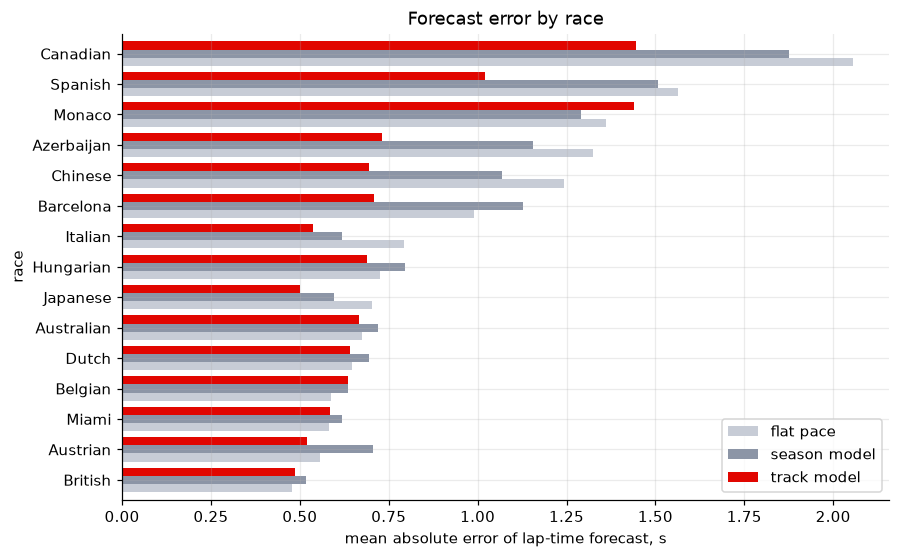

track model beats the flat baseline in 11 of 15 races


In [10]:
v = lodo.set_index('race')[['mae_baseline', 'mae_model']].join(
    loro.set_index('race')[['mae_model']].rename(columns={'mae_model': 'mae_season'}))
v = v.sort_values('mae_baseline')
ax = v[['mae_baseline', 'mae_season', 'mae_model']].rename(columns={
    'mae_baseline': 'flat pace', 'mae_season': 'season model', 'mae_model': 'track model'}).plot.barh(
    color=['#c7ccd6', '#8c95a6', '#e10600'], figsize=(9, 5.5), width=.8)
ax.set_yticklabels([r.replace(' Grand Prix', '') for r in v.index])
ax.set(xlabel='mean absolute error of lap-time forecast, s', title='Forecast error by race')
plt.show()
print(f'track model beats the flat baseline in {(lodo.mae_model < lodo.mae_baseline).sum()} of {len(lodo)} races')

## 7. Strategy case: Belgian Grand Prix
With a track-specific model we can price every one-stop strategy:
`race time(stop lap) = Σ stint 1 + Σ stint 2 + pit loss`. Pit loss is measured from the data
(in-lap + out-lap − 2 × driver's median clean lap, green-flag stops only).

In [11]:
RACE = 'Belgian Grand Prix'
raw_r, clean_r = laps[laps.race == RACE], clean[clean.race == RACE]
race_model = M.fit_race(clean_r, fuel_fixed)
p = M.race_params(race_model)
loss, n_stops = S.pit_loss(raw_r, clean_r)
N = int(raw_r.total_laps.iloc[0])
print(f'{RACE}: {N} laps · pit loss {loss:.1f} s (median of {n_stops} stops)')
print('degradation, s/lap:', {c: round(v, 3) for c, v in p['deg'].items()})
print('new-tyre pace vs MEDIUM, s:', {c: round(v, 2) for c, v in p['offset'].items()})

Belgian Grand Prix: 45 laps · pit loss 23.0 s (median of 8 stops)
degradation, s/lap: {'HARD': 0.026, 'MEDIUM': 0.065, 'SOFT': 0.236}
new-tyre pace vs MEDIUM, s: {'SOFT': -1.13, 'MEDIUM': 0.0, 'HARD': 0.26}


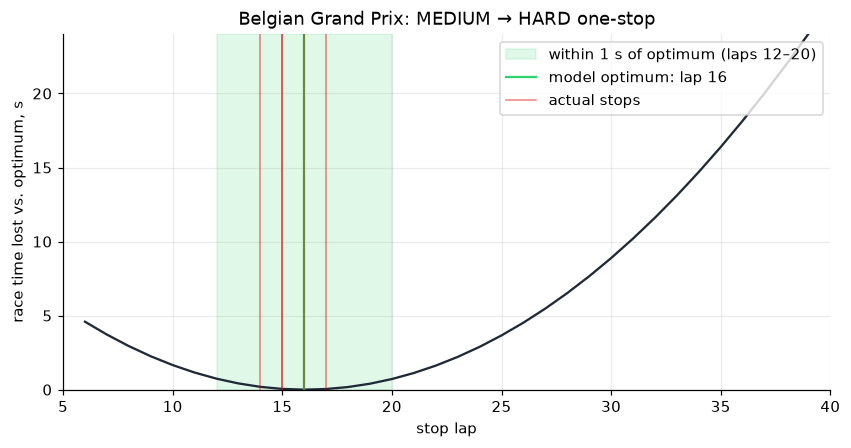

,3,2,6,8,13
driver,GAS,COL,LAW,LIN,VER
stop_lap,14,15,15,16,17


In [12]:
actual = S.actual_one_stops(raw_r)
actual = actual[~actual.under_neutralisation & (actual['first'] == 'MEDIUM') & (actual['second'] == 'HARD')]
curve = S.one_stop_curve(p, N, 'MEDIUM', 'HARD', loss)
best, lo, hi = S.optimal_window(curve)

fig, ax = plt.subplots()
ax.plot(curve.stop_lap, curve.delta, color='#1f2937')
ax.axvspan(lo, hi, color='#2fd36b', alpha=.15, label=f'within 1 s of optimum (laps {lo}–{hi})')
ax.axvline(best, color='#2fd36b', lw=1.5, label=f'model optimum: lap {best}')
for i, (_, r) in enumerate(actual.iterrows()):
    ax.axvline(r.stop_lap, color='#e10600', alpha=.5, lw=1, label='actual stops' if i == 0 else None)
ax.set(xlim=(5, N - 5), ylim=(0, curve.delta[(curve.stop_lap > 5) & (curve.stop_lap < N - 5)].max()),
       xlabel='stop lap', ylabel='race time lost vs. optimum, s', title=f'{RACE}: MEDIUM → HARD one-stop')
ax.legend(); plt.show()
actual.sort_values('stop_lap')[['driver', 'stop_lap']].T

The model's window and the laps the teams actually chose overlap — the optimum is
also very flat: being a few laps early or late costs well under a second, which is why teams
can afford to react to traffic and rivals.

**Undercut.** How much a driver on fresh hards gains per lap on a rival who stays out on
worn mediums (first-lap warm-up measured from the data):

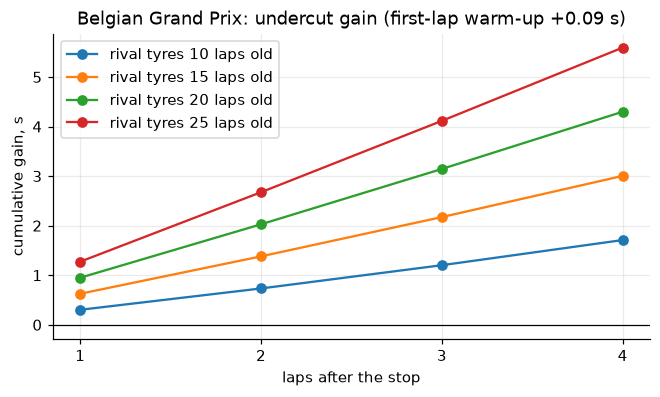

In [13]:
warmup = S.warmup_penalty(clean_r, race_model)
fig, ax = plt.subplots(figsize=(7, 3.6))
for age in (10, 15, 20, 25):
    g = S.undercut_gain(p, 'MEDIUM', age, 'HARD', laps=4, warmup=warmup)
    ax.plot(range(1, 5), g, 'o-', label=f'rival tyres {age} laps old')
ax.axhline(0, color='k', lw=.8)
ax.set(xticks=range(1, 5), xlabel='laps after the stop', ylabel='cumulative gain, s',
       title=f'{RACE}: undercut gain (first-lap warm-up {warmup:+.2f} s)')
ax.legend(); plt.show()

## 8. Model optimum vs. reality across the season
Only race/strategy pairs where at least three drivers made a green-flag one-stop with that
compound pair and both degradation estimates are positive.

In [14]:
rows = []
for race in laps.race.unique():
    raw_r, clean_r = laps[laps.race == race], clean[clean.race == race]
    try:
        pr = M.race_params(M.fit_race(clean_r, fuel_fixed))
    except ValueError:
        continue
    loss_r, _ = S.pit_loss(raw_r, clean_r)
    n = int(raw_r.total_laps.iloc[0])
    st = S.actual_one_stops(raw_r)
    st = st[~st.under_neutralisation]
    for (a, b), g in st.groupby(['first', 'second']):
        if a == b or len(g) < 3 or min(pr['deg'].get(a, -1), pr['deg'].get(b, -1)) <= 0:
            continue
        best_r, lo_r, hi_r = S.optimal_window(S.one_stop_curve(pr, n, a, b, loss_r))
        rows.append({'race': race.replace(' Grand Prix', ''), 'strategy': f'{a} → {b}',
                     'drivers': len(g), 'model optimum': best_r, 'window ±1 s': f'{lo_r}–{hi_r}',
                     'actual (median)': g.stop_lap.median(),
                     'actual − optimum': g.stop_lap.median() - best_r})
pd.DataFrame(rows)

,race,strategy,drivers,model optimum,window ±1 s,actual (median),actual − optimum
0,Chinese,HARD → MEDIUM,4,47,42–50,33.5,-13.5
1,Japanese,MEDIUM → HARD,9,7,6–15,18.0,11.0
2,Miami,MEDIUM → HARD,14,34,30–38,27.5,-6.5
3,Belgian,MEDIUM → HARD,5,16,12–20,15.0,-1.0


* **Belgium** — the model and the teams agree within one lap.
* **Miami** — teams stopped ~6 laps **earlier** than the "isolated" optimum. Expected: the model
  optimises one car in clean air, while real strategy is a game — pitting first gains the
  undercut and protects track position.
* **China, Japan** — far off. Here one compound's estimated degradation is close to zero and the
  hard tyre looks *faster* than the medium. That is mostly **track evolution**: the hard is run
  in the second half of the race on a faster, rubbered-in track. With wear this low the optimum
  is driven by those pace offsets and the model is unreliable — the weakest spot of a linear,
  per-race model (see below).

## 9. Limitations & next steps
* **Linear degradation.** Real tyres have a warm-up phase and sometimes a "cliff"; a piecewise or
  spline term in tyre age would capture both.
* **Track evolution vs. wear.** The track rubbers in during a race, which looks like *negative*
  degradation on low-wear circuits. Practice-session long runs or a race-wide time trend could
  separate the two.
* **Traffic and dirty air** are not modelled — following another car costs pace and wear.
* **Fuel** is a single season-wide linear term; real burn rate differs by track.
* **2026 is a new rule set** (new cars, active aero, overtake mode) — the season sample is
  15 races, so per-track estimates have wide intervals.

Next: two-stop strategies and Safety-Car-aware expected race time (simulate SC probability per
lap), and plugging the per-track model into the live timing app as a pit-window panel.